In [1]:
import glob, os
print([d for d in os.listdir("data/keypoints")])   # find the SLR folder

['.DS_Store', 'bsq', 'cmj', 'dj', 'hip', 'nordic', 'ohp', 'rjt', 'slr', 'slsq']


16 files


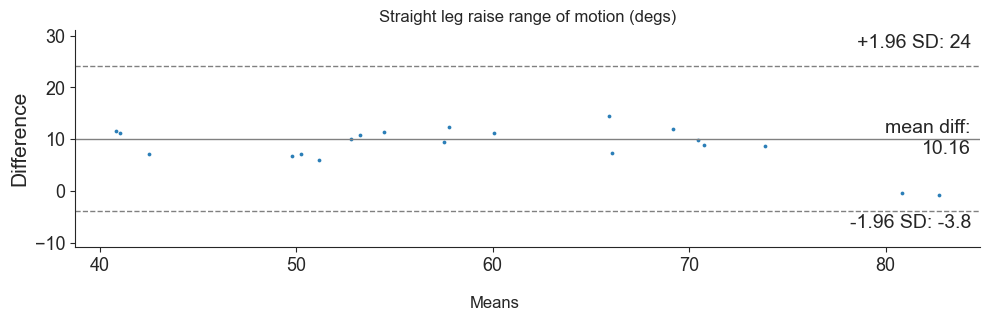

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Range of motion,Straight leg raise,N/A,Optical motion capture,10.26,0.78,0.64


In [2]:
from utilities import utils
from tasks import slr

slr_files = sorted(p for p in glob.glob("data/keypoints/slr/*.txt") if "world" not in p.lower())
slr_data = utils.read_list('slr_data')
print(len(slr_files), "files")

m = slr.get_metrics(slr_files, slr_data)
m

In [3]:
import os
from utilities import utils

# hip folder name + files
print("hip folder contents sample:", os.listdir("data/keypoints/hip")[:4])

# hip pickle structure
hip_data = utils.read_list('hip_data')
print("hip keys:", hip_data[0].keys())                    # expect 'hir','her'?
print("sub keys:", hip_data[0][list(hip_data[0].keys())[0]].keys())  # parts

hip folder contents sample: ['P03_HER_FRONT.txt', 'P03_HER_FRONT_world.txt', 'P03_HIR_FRONT.txt', 'P03_HIR_FRONT_world.txt']
hip keys: dict_keys(['her', 'hir'])
sub keys: dict_keys(['ankle', 'knee'])


In [1]:
import inspect
from utilities import utils

# hip pickle structure
hip_data = utils.read_list('hip_data')
print("hip keys:", hip_data[0].keys())                          # 'hir','her'?
k = list(hip_data[0].keys())[0]
print("task sub-keys:", hip_data[0][k].keys())                  # parts: knee, ankle?
print("knee op shape:", hip_data[0][k]['knee']['op'].shape)

# the angle function hip uses
print(inspect.getsource(utils.intersection_angle))

hip keys: dict_keys(['her', 'hir'])
task sub-keys: dict_keys(['ankle', 'knee'])
knee op shape: (1575, 3)
def intersection_angle(line1, line2):
    np.seterr(divide='ignore', invalid='ignore')
    vec11, vec12 = [handle_zeros_nans(l) for l in line1]
    vec21, vec22 = [handle_zeros_nans(l) for l in line2]
    # m = y2-y1 / x2-x1
    m1 = (vec12[:,1]-vec11[:,1])/(vec12[:,0]-vec11[:,0])
    m2 = (vec22[:,1]-vec21[:,1])/(vec22[:,0]-vec21[:,0])
    theta = np.arctan(abs((m2-m1)/(1+(m1*m2))))
    theta = pd.Series(theta).interpolate() # handle nans
    theta = np.degrees(theta.to_numpy())

    return theta



[hip] P06 her: 3/2 reps, skipped


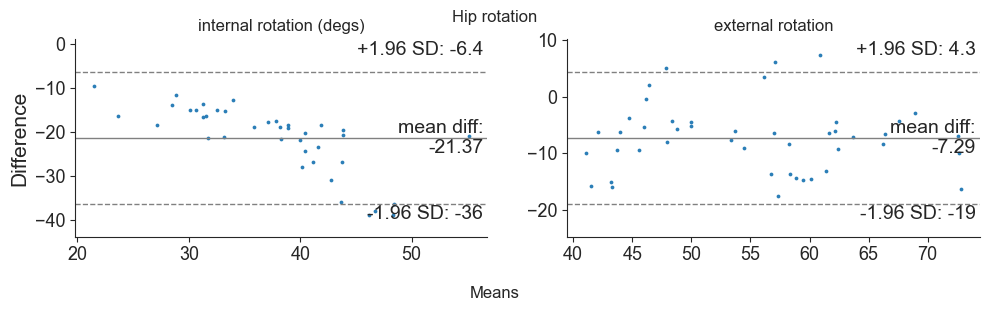

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Range of motion,Hip internal rotation,N/A,Optical motion capture,21.37,0.87,0.13
1,Range of motion,Hip external rotation,N/A,Optical motion capture,8.36,0.94,0.63


In [2]:
from utilities import utils
from tasks import hip

hip_data = utils.read_list('hip_data')
m = hip.get_metrics("data/keypoints/hip", hip_data)
m

In [3]:
import os
from tasks import hip
for sid in ["P03","P04","P05","P06","P08"]:
    her = hip._find_file("data/keypoints/hip", sid, "her")
    hir = hip._find_file("data/keypoints/hip", sid, "hir")
    print(f"{sid}: her->{os.path.basename(her) if her else None}")
    print(f"     hir->{os.path.basename(hir) if hir else None}")

P03: her->P03_HER_FRONT.txt
     hir->P03_HIR_FRONT.txt
P04: her->P04_HIP_ER_FRONT.txt
     hir->P04_HIP_IR_FRONT.txt
P05: her->P05_HIP_ER_FRONT.txt
     hir->P05_HIP_IR_FRONT.txt
P06: her->P06_HIP_ER_FRONT.txt
     hir->P06_HIP_IR_FRONT.txt
P08: her->P08_HIP_ER_4X_FRONT.txt
     hir->P08_HIP_IR_FRONT.txt


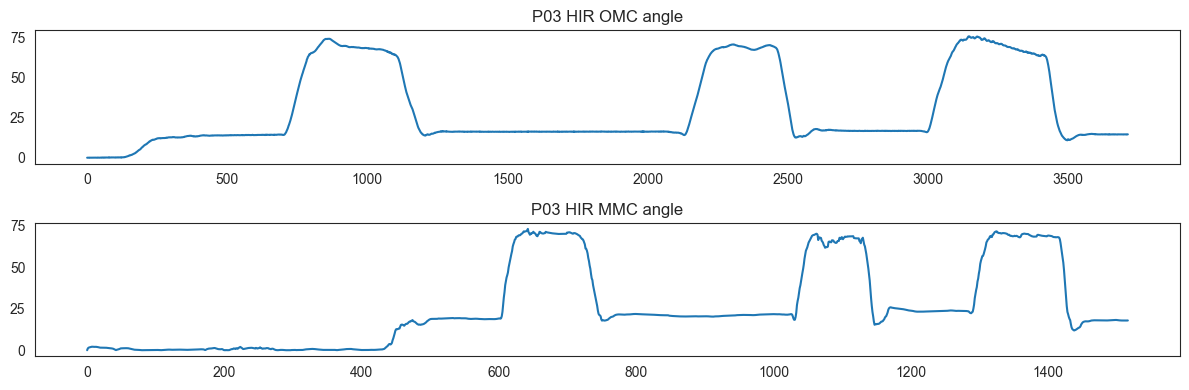

In [4]:
import numpy as np, matplotlib.pyplot as plt
from tasks import hip
sid, a = "P03", 0
fp = hip._find_file("data/keypoints/hip", sid, "hir")
mmc = hip._mmc_angle(fp)
omc = hip._omc_angle(hip_data[a], "hir")
fig, ax = plt.subplots(2,1, figsize=(12,4))
ax[0].plot(omc); ax[0].set_title(f"{sid} HIR OMC angle")
ax[1].plot(mmc); ax[1].set_title(f"{sid} HIR MMC angle")
plt.tight_layout(); plt.show()

OMC reps: 3   MMC reps: 3
OMC ROMs: [np.float64(60.2), np.float64(57.9), np.float64(64.5)]
MMC ROMs: [np.float64(54.0), np.float64(54.3), np.float64(57.2)]


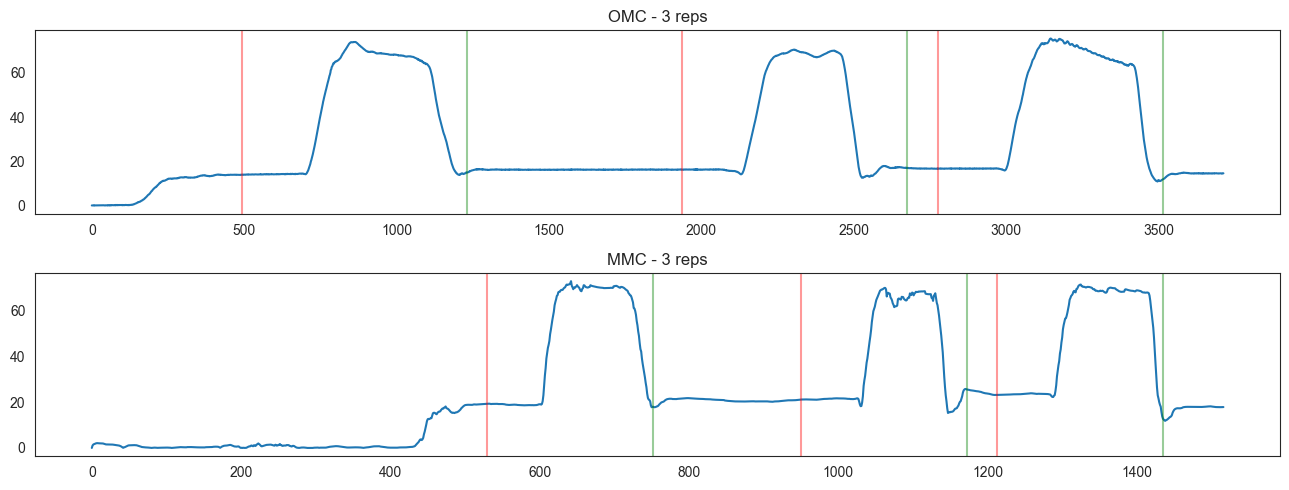

In [5]:
import numpy as np
from utilities import utils
from tasks import hip
import matplotlib.pyplot as plt

sid, a = "P03", 0
fp = hip._find_file("data/keypoints/hip", sid, "hir")
mmc = hip._mmc_angle(fp)
omc = hip._omc_angle(hip_data[a], "hir")

cseg, creps = utils.get_reps(omc, fps=100, plot=False, d=8, forward=3.7, rewind=3.7)
oseg, oreps = utils.get_reps(mmc, fps=30, plot=False, d=7, forward=3.7, rewind=3.7)
print("OMC reps:", len(creps), "  MMC reps:", len(oreps))

# show what each rep's max-min ROM comes out as
print("OMC ROMs:", [round(max(r)-min(r),1) for r in creps[-3:]])
print("MMC ROMs:", [round(max(r)-min(r),1) for r in oreps[-3:]])

fig, axs = plt.subplots(2,1, figsize=(13,5))
axs[0].plot(omc); axs[0].set_title(f"OMC - {len(creps)} reps")
for s in cseg: axs[0].axvline(s[0],color='r',alpha=.4); axs[0].axvline(s[1],color='g',alpha=.4)
axs[1].plot(mmc); axs[1].set_title(f"MMC - {len(oreps)} reps")
for s in oseg: axs[1].axvline(s[0],color='r',alpha=.4); axs[1].axvline(s[1],color='g',alpha=.4)
plt.tight_layout(); plt.show()

HER OMC ROMs: [np.float64(23.1), np.float64(24.4), np.float64(27.6)]
HER MMC ROMs: [np.float64(34.6), np.float64(38.0), np.float64(40.3)]


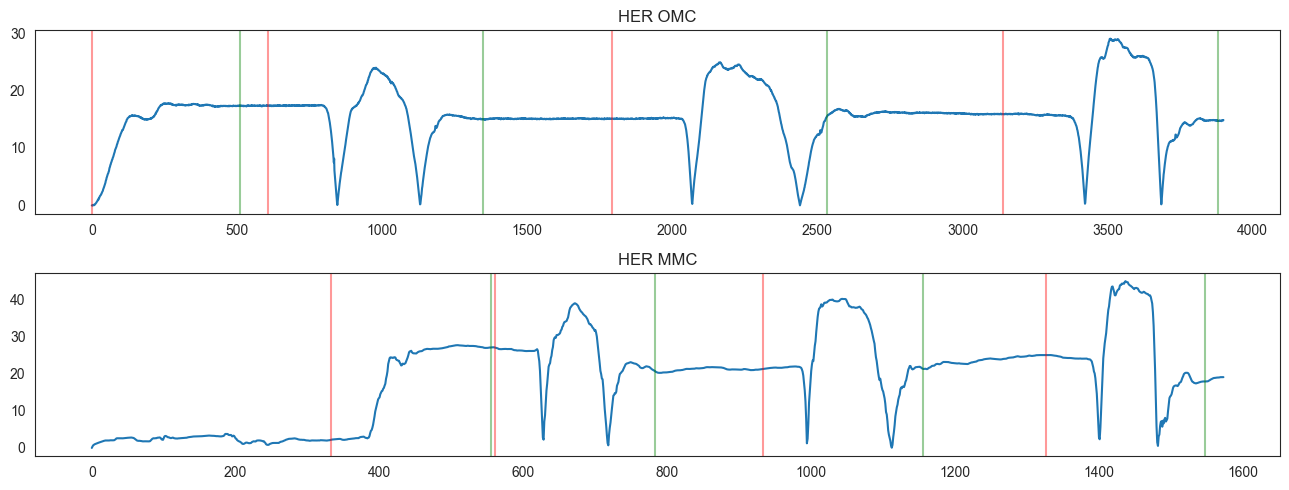

In [6]:
import numpy as np, matplotlib.pyplot as plt
from utilities import utils
from tasks import hip

sid, a = "P03", 0
fp = hip._find_file("data/keypoints/hip", sid, "her")   # ER this time
mmc = hip._mmc_angle(fp)
omc = hip._omc_angle(hip_data[a], "her")
cseg, creps = utils.get_reps(omc, fps=100, plot=False, d=8, forward=3.7, rewind=3.7)
oseg, oreps = utils.get_reps(mmc, fps=30, plot=False, d=7, forward=3.7, rewind=3.7)
print("HER OMC ROMs:", [round(max(r)-min(r),1) for r in creps[-3:]])
print("HER MMC ROMs:", [round(max(r)-min(r),1) for r in oreps[-3:]])

fig, axs = plt.subplots(2,1, figsize=(13,5))
axs[0].plot(omc); axs[0].set_title("HER OMC"); 
for s in cseg: axs[0].axvline(s[0],color='r',alpha=.4); axs[0].axvline(s[1],color='g',alpha=.4)
axs[1].plot(mmc); axs[1].set_title("HER MMC")
for s in oseg: axs[1].axvline(s[0],color='r',alpha=.4); axs[1].axvline(s[1],color='g',alpha=.4)
plt.tight_layout(); plt.show()

In [7]:
her_df, hir_df = hip.get_range_of_motion("data/keypoints/hip", hip_data)
# the 'internal rotation' metric uses her_df with the swap
print("HER per-rep (feeds 'internal' metric):")
print(her_df[['coda_her_1','op_her_1']].round(1))

[hip] P06 her: 3/2 reps, skipped
HER per-rep (feeds 'internal' metric):
    coda_her_1  op_her_1
0         23.1      34.6
1         27.3      58.3
2         25.6      40.8
3         29.4      48.5
4         21.1      42.4
5         28.7      47.7
6         26.2      54.1
7         29.8      53.3
8         44.6      65.6
9         16.7      26.2
10        28.9      67.8
11        22.6      37.6
12        30.3      50.5
